In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load the Bars from path
paths = {
  "Tick": Path("../data/es_tick_bars.csv"),
  "Volume": Path("../data/es_volume_bars.csv"),
  "Dollar": Path("../data/es_dollar_bars.csv")
}

# Notify if files are missing
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing files: {', '.join(missing)}")


# read the CSV files into DataFrames
tick_bars = pd.read_csv(paths["Tick"], parse_dates=["timestamp"])
volume_bars = pd.read_csv(paths["Volume"], parse_dates=["timestamp"])
dollar_bars = pd.read_csv(paths["Dollar"], parse_dates=["timestamp"])

# print the bars
print("Tick:", len(tick_bars))
print("Volume:", len(volume_bars))
print("Dollar:", len(dollar_bars))

Tick: 150
Volume: 149
Dollar: 149


In [3]:
# Calculate the log returns

def add_log_returns(bars):
    x = bars.copy()
    x["log_return"] = np.log(x["close"] / x["close"].shift(1))
    return x.dropna(subset=["log_return"])

tick_bars = add_log_returns(tick_bars)
volume_bars = add_log_returns(volume_bars)
dollar_bars = add_log_returns(dollar_bars)

display(tick_bars[["timestamp", "close", "log_return"]].head())
display(volume_bars[["timestamp", "close", "log_return"]].head())
display(dollar_bars[["timestamp", "close", "log_return"]].head())


,timestamp,close,log_return
1,2013-09-01 19:20:09.224,1641.50,0.000609
2,2013-09-01 20:44:29.770,1642.25,0.000457
3,2013-09-01 23:13:07.101,1643.00,0.000457
4,2013-09-02 01:29:18.999,1644.00,0.000608
5,2013-09-02 02:08:37.675,1643.50,-0.000304


,timestamp,close,log_return
1,2013-09-01 19:09:34.288,1640.75,0.000152
2,2013-09-01 20:22:03.553,1642.50,0.001066
3,2013-09-02 00:00:47.925,1643.00,0.000304
4,2013-09-02 02:00:48.477,1643.50,0.000304
5,2013-09-02 02:25:26.240,1645.00,0.000912


,timestamp,close,log_return
1,2013-09-01 19:09:34.288,1640.75,0.000152
2,2013-09-01 20:22:59.983,1642.50,0.001066
3,2013-09-02 00:00:47.925,1643.00,0.000304
4,2013-09-02 02:00:46.464,1643.50,0.000304
5,2013-09-02 02:25:26.240,1645.00,0.000912


In [4]:
# calculate the autocorrelation of log returns

returns = {
  "Tick": tick_bars["log_return"].autocorr(lag=1),
  "Volume": volume_bars["log_return"].autocorr(lag=1),
  "Dollar": dollar_bars["log_return"].autocorr(lag=1)
}

autocorr_table = pd.DataFrame.from_dict(
  returns,
  orient="index",
  columns=["Lag-1 Autocorrelation"]
)

autocorr_table["Absolute Autocorrelation"] = autocorr_table["Lag-1 Autocorrelation"].abs()
autocorr_table = autocorr_table.sort_values(by="Absolute Autocorrelation")
display(autocorr_table)

,Lag-1 Autocorrelation,Absolute Autocorrelation
Tick,-0.158737,0.158737
Volume,-0.217514,0.217514
Dollar,-0.229545,0.229545


In [5]:
# identify lowest serial correlation
lowest = autocorr_table["Absolute Autocorrelation"].idxmin()

print("Lowest serial correlation is found in:", lowest)
display(autocorr_table.loc[[lowest]])

Lowest serial correlation is found in: Tick


,Lag-1 Autocorrelation,Absolute Autocorrelation
Tick,-0.158737,0.158737


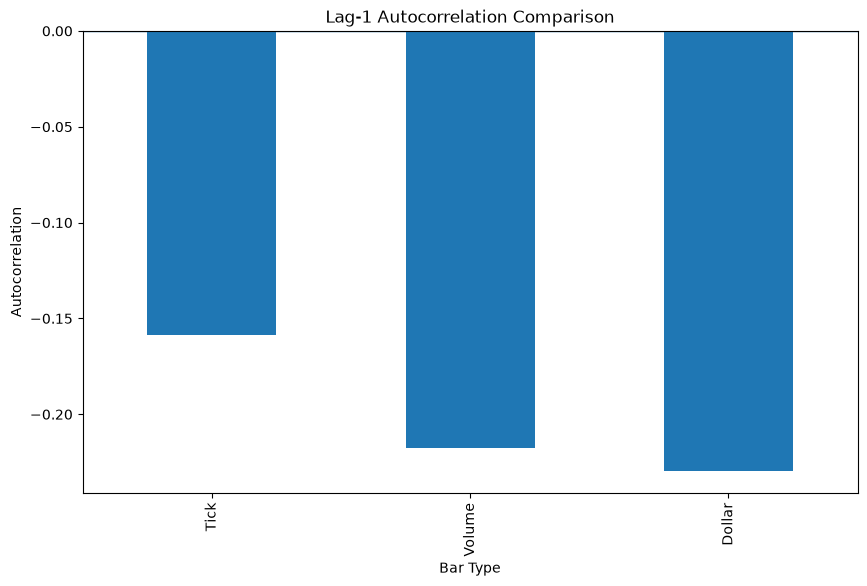

In [6]:
# Plot the comparison
plt.figure(figsize=(10, 6))
autocorr_table["Lag-1 Autocorrelation"].plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("Lag-1 Autocorrelation Comparison")
plt.xlabel("Bar Type")
plt.ylabel("Autocorrelation")
plt.show()

In [7]:
# inspect lags 1 - 10
def autocorr_by_lag(series, max_lag=10):
    return pd.Series({
      lag: series.autocorr(lag=lag)
      for lag in range(1, max_lag + 1)
    })

multi_lag = pd.DataFrame({
    "Tick": autocorr_by_lag(tick_bars["log_return"]),
    "Volume": autocorr_by_lag(volume_bars["log_return"]),
    "Dollar": autocorr_by_lag(dollar_bars["log_return"])
})

multi_lag.index.name = "Lag"
display(multi_lag)

,Tick,Volume,Dollar
Lag,,,
1,-0.158737,-0.217514,-0.229545
2,-0.015718,-0.013367,0.029735
3,-0.124471,-0.072400,-0.128399
4,0.076700,0.100342,0.098902
5,0.142303,-0.005947,0.055361
6,-0.064178,-0.006120,-0.053950
7,-0.031799,0.073114,0.052826
8,0.067121,-0.000236,0.031742
9,0.001926,-0.009081,-0.011277


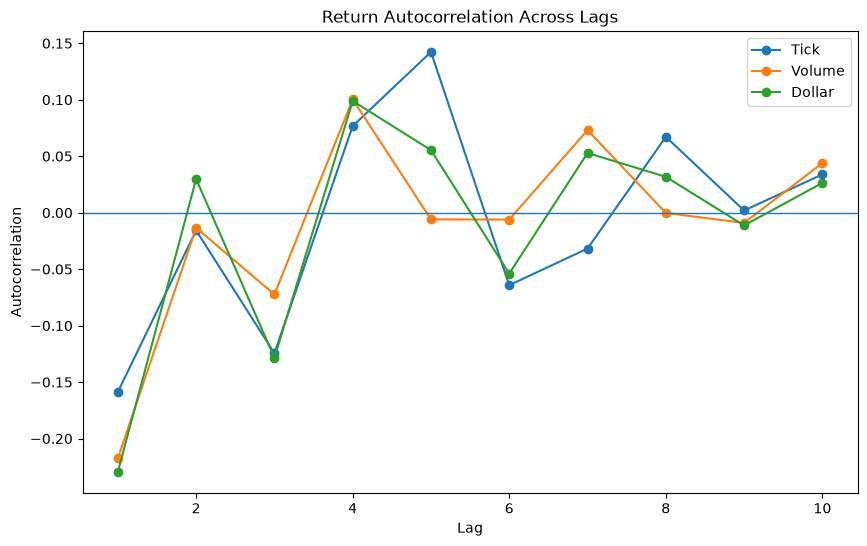

In [8]:
# plot the multi-lag autocorrelation
plt.figure(figsize=(10, 6))
plt.plot(multi_lag.index, multi_lag["Tick"], label="Tick", marker="o")
plt.plot(multi_lag.index, multi_lag["Volume"], label="Volume", marker="o")
plt.plot(multi_lag.index, multi_lag["Dollar"], label="Dollar", marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Return Autocorrelation Across Lags")
plt.legend()
plt.show()